* https://github.com/hse-ling-python/seminars/blob/master/vector_models/vector_models_25_26.ipynb
* https://networkx.org/documentation/stable/reference/algorithms/community.html

Идея: берем модель Word2Vec, как вершины берем слова, соединяем ребрами слова, которые модель считает наиболее похожими, ищем сообщества специальным алгоритмом, получаем лексические кластеры  
Идея не моя и возможно очевидная

Оригинальная заметка: Берем вордтувек считаем там пары слов с семантической близостью больше типа там 0.5 например и выделяем сообщества (идея впрочем не моя а мб Зыковой но очевидная но интересно просто результат посмотреть)

новая идея: автоматическое выделение семантических полей  
мб чтобы понижать порог не делать новый граф а убирать из имеющегося ребра с весом меньше данного

мб от мусора отфильтровать малочастотные слова

In [1]:
import networkx as nx
from gensim.models import KeyedVectors
import numpy as np
from tqdm import tqdm
import joblib

Качаем модель:

In [ ]:
!wget https://rusvectores.org/static/models/rusvectores4/RNC/ruscorpora_upos_skipgram_300_5_2018.vec.gz

Загружаем модель:

In [2]:
model = KeyedVectors.load_word2vec_format('ruscorpora_upos_skipgram_300_5_2018.vec.gz')

In [3]:
model.most_similar('кошка_NOUN', topn=5)

[('кот_NOUN', 0.7805721759796143),
 ('собака_NOUN', 0.7084056735038757),
 ('котенок_NOUN', 0.6833623647689819),
 ('мяукать_VERB', 0.661374568939209),
 ('мяукать_NOUN', 0.6479178071022034)]

Строим граф:

In [71]:
w2v_graph = nx.Graph()
for word in tqdm(model.index_to_key):
    w2v_graph.add_node(word)
    w2v_graph.add_edges_from(list(zip([word] * 5, [i[0] for i in model.most_similar(word, topn=5)])))

100%|██████████| 195071/195071 [36:18<00:00, 89.56it/s]  


In [73]:
joblib.dump(w2v_graph, 'w2v_graph.joblib')

['w2v_graph.joblib']

Создаем класс для хранения кластеров и графа:

In [74]:
class SemClusters():
    def __init__(self):
        pass

    def create_from_list(self, list):
        '''
        Create SemClusters from list of clusters
        '''
        self.clusters = list

        return self

    def create_from_graph(self, graph: nx.Graph):
        '''
        Create SemClusters from a given graph
        '''
        self.clusters = [i for i in nx.algorithms.community.label_propagation.asyn_lpa_communities(graph)]
        self.graph = graph

        return self

    def create_from_model(self, model):
        '''
        Create SemClusters from a given word2vec model
        '''
        w2v_graph = nx.Graph()
        for word in tqdm(model.index_to_key):
            w2v_graph.add_node(word)
            w2v_graph.add_edges_from(list(zip([word] * 5, [i[0] for i in model.most_similar(word, topn=5)])))

        return self.create_from_graph(self, w2v_graph)

    def get_cluster(self, word):
        '''
        Get cluster to which a word belongs
        '''
        res = []
        for cluster in self.clusters:
            if word in cluster:
                res.append(cluster)

        return res

    def save(self, name):
        '''
        Save list of clusters via joblib
        '''
        joblib.dump(self.clusters, name)

In [350]:
clusts = SemClusters().create_from_graph(w2v_graph)

In [351]:
clusts.save('clusts.joblib')

Протестируем:

In [122]:
clusts.get_cluster('собирать_VERB')

[{'собираемый_VERB',
  'собирать_ADV',
  'собирать_NOUN',
  'собирать_VERB',
  'собрать_VERB'}]

Сколько получилось кластеров:

In [110]:
len(clusts.clusters)

10181

In [ ]:
f = np.array([len(i) for i in clusts.clusters])
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()
sns.boxplot(f)
plt.ylim(0, 30)
plt.show()

## Louvain

Сделаем другим алгоритмом поиска сообществ:

In [111]:
louvain = nx.algorithms.community.louvain.louvain_communities(w2v_graph)

In [112]:
len(louvain)

36

In [75]:
def get_cluster(clusters, word):
    '''
    Get cluster to which a word belongs
    '''
    res = []
    for cluster in clusters:
        if word in cluster:
            res.append(cluster)

    return res

In [230]:
get_cluster(louvain, 'умереть_VERB')

[{'иосаф_PROPN',
  'плавин_PROPN',
  'марг_PROPN',
  'поговоривша_VERB',
  'анисья::петровна_PROPN',
  'княгиня_PROPN',
  'незавидный_ADV',
  'ид_VERB',
  'превосходительствотец_NOUN',
  'верят_NOUN',
  'лужин_PROPN',
  'чурасов_PROPN',
  'климук_PROPN',
  'приятельница_NOUN',
  'виноватый_PROPN',
  'ченцов_PROPN',
  'оскорбительный_ADV',
  'парфений::иванович_PROPN',
  'гофтреппе_PROPN',
  'аничка_NOUN',
  'ирен_PROPN',
  'грейфенфельд_PROPN',
  'ельников_PROPN',
  'вежливо_ADV',
  'о.::а_PROPN',
  'бродников_PROPN',
  'главкон_PROPN',
  'меня_NOUN',
  'грун_ADV',
  'друг_ADJ',
  'флоренс_PROPN',
  'пускай_NOUN',
  'грунюшка_PROPN',
  'панталеон_PROPN',
  'досказать_VERB',
  'евсей::евсеич_PROPN',
  'возражатель_NOUN',
  'заключенье_NOUN',
  'николушка_PROPN',
  'умный_PROPN',
  'благопожелание_NOUN',
  'кичливо_ADV',
  'ninon_PROPN',
  'бережно_ADV',
  'лояльно_ADV',
  'сусанна::николаевна_PROPN',
  'незамужний_ADJ',
  'мадам_PROPN',
  'книжка_ADV',
  'сталотреть_ADJ',
  'зинаида::вл

## Другой label propagation

In [ ]:
def create_from_graph_lprop(graph: nx.Graph):
    '''
    Create list of clusters from a given graph
    '''
    return [i for i in nx.algorithms.community.label_propagation.label_propagation_communities(graph)]

In [125]:
lprop = create_from_graph_lprop(w2v_graph)

In [126]:
len(lprop)

8981

In [347]:
get_cluster(lprop, 'поле_NOUN')

[{'борозда_NOUN',
  'вспаханный_ADJ',
  'вспаханный_VERB',
  'вспахать_ADJ',
  'выпахать_VERB',
  'жнивье_NOUN',
  'заливной_ADJ',
  'заливный_ADJ',
  'засеянный_ADJ',
  'засеянный_VERB',
  'засеять_ADJ',
  'засеять_VERB',
  'конца-край_NOUN',
  'луг_NOUN',
  'луговой_ADJ',
  'луговый_ADJ',
  'меж_NOUN',
  'невозделанный_ADJ',
  'незасеянный_ADJ',
  'незасеять_ADJ',
  'некошеный_ADJ',
  'непаханый_ADJ',
  'нескошенный_ADJ',
  'пажить_NOUN',
  'пашня_ADJ',
  'поемный_ADJ',
  'поле_NOUN',
  'поле_VERB',
  'полю_NOUN',
  'поля_NOUN',
  'пустоша_NOUN',
  'распаханный_ADJ',
  'распаханный_VERB',
  'распахать_ADJ',
  'распахать_VERB',
  'ржаный_ADJ',
  'скосить_ADJ',
  'стерн_NOUN',
  'стернь_NOUN',
  'стерня_NOUN'}]

## Загружаем

In [8]:
f = joblib.load('clusts.joblib')
f = SemClusters().create_from_list(f)

## Тестим Louvain чтобы давал больше классов

In [15]:
louvain = nx.algorithms.community.louvain.louvain_communities(w2v_graph, max_level=1)

In [59]:
len(louvain)

15378

In [49]:
get_cluster(louvain, 'картинка_NOUN')

[{'акварелька_NOUN',
  'гномик_NOUN',
  'картинка_NOUN',
  'картиночка_NOUN',
  'красочка_NOUN',
  'лубочный_ADJ',
  'мазилка_NOUN',
  'мазня_NOUN',
  'олеография_NOUN',
  'пейзажик_NOUN',
  'портретик_NOUN',
  'рисуночек_NOUN'}]

In [60]:
joblib.dump(louvain, 'louvain.joblib')

['louvain.joblib']

## Что-то

In [12]:
clusts_thr_06 = joblib.load('clusts_thr_06.joblib')
clusts_thr_06 = SemClusters().create_from_list(clusts_thr_06)

In [21]:
clusts_thr_06.get_cluster('мышь_NOUN')

[{'кролик_NOUN', 'крыса_NOUN', 'мышь_NOUN', 'мышь_PROPN', 'таракан_NOUN'}]

## Взвешенный

In [6]:
w_graph = joblib.load('w2v_graph_w.joblib')

In [ ]:
weighted = list(nx.algorithms.community.label_propagation.asyn_lpa_communities(w_graph, weight='weight'))

In [66]:
len(weighted)

22352

In [ ]:
joblib.dump(weighted, 'weighted_clusters.joblib')

In [8]:
weighted = SemClusters().create_from_list(joblib.load('weighted_clusters.joblib'))

In [11]:
get_cluster(joblib.load('weighted_clusters.joblib'), 'компьютер_NOUN')

[{'-автомат_NOUN',
  '-диск_NOUN',
  '-диска_NOUN',
  '-компьютер_NOUN',
  '-плейер_NOUN',
  '-проигрыватель_NOUN',
  'cd_PROPN',
  'dvd_NOUN',
  'dvd_PROPN',
  'enter_PROPN',
  'ipod_PROPN',
  'itunes_PROPN',
  'mp3_PROPN',
  'sony_NOUN',
  'vhs_PROPN',
  'адаптер_NOUN',
  'айпад_NOUN',
  'айфон_NOUN',
  'астры_NOUN',
  'аудио_NOUN',
  'аудиокассета_NOUN',
  'баг_NOUN',
  'бардачка_NOUN',
  'биг::биз_PROPN',
  'брейн_NOUN',
  'вампонавигатор_NOUN',
  'видео_NOUN',
  'видеоаппаратура_NOUN',
  'видеоизображение_NOUN',
  'видеокассет_NOUN',
  'видеокассета_NOUN',
  'видеокассета_VERB',
  'видеоклип_NOUN',
  'видеомагнитофон_NOUN',
  'видеомагнитофоный_NOUN',
  'видеоплейер_NOUN',
  'видеоролик_NOUN',
  'видеотека_NOUN',
  'видеотелефон_NOUN',
  'видеотехника_NOUN',
  'видеофильм_NOUN',
  'видеофон_NOUN',
  'гадзывать_NOUN',
  'гидрофон_NOUN',
  'голд_NOUN',
  'дактилоскопический_ADJ',
  'девайс_NOUN',
  'декодер_NOUN',
  'диафильм_NOUN',
  'дивиди_NOUN',
  'дивиди_PROPN',
  'диктофон_NOU

## новое к матлингу

отфильтруем наверное только глаголы. и основная цель будет выделять семантические поля  
будем еще считать какие-то метрики мб

In [76]:
import networkx as nx
from gensim.models import KeyedVectors
import numpy as np
from tqdm import tqdm
import joblib

In [78]:
model = KeyedVectors.load_word2vec_format('ruscorpora_upos_skipgram_300_5_2018.vec.gz')

In [ ]:
w2v_graph_w_verbs = nx.Graph()
for word in tqdm(model.index_to_key):
    if 'VERB' in word:
        for neigh, weight in model.most_similar(word, topn=10):
            if 'VERB' in neigh and weight > 0.7:
                w2v_graph_w_verbs.add_edge(word, neigh, weight=1/weight)

100%|██████████| 195071/195071 [05:56<00:00, 547.77it/s] 


In [20]:
weighted = list(nx.algorithms.community.label_propagation.asyn_lpa_communities(w2v_graph_w_verbs, weight='weight'))

In [23]:
len(w2v_graph_w_verbs.nodes)

13840

In [21]:
len(weighted)

3371

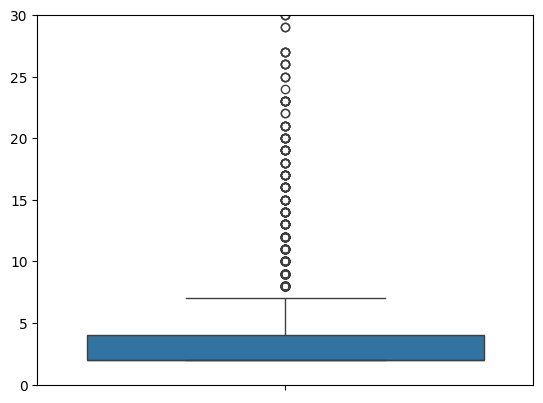

In [22]:
f = np.array([len(i) for i in weighted])
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()
sns.boxplot(f)
plt.ylim(0, 30)
plt.show()

In [28]:
get_cluster(weighted, 'умирать_VERB')

[{'перемереть_VERB',
  'перемирать_VERB',
  'помереть_VERB',
  'помирае_VERB',
  'помирать_VERB',
  'помрать_VERB',
  'помрий_VERB',
  'помрть_VERB',
  'пришибть_VERB',
  'разойдиваться_VERB',
  'умирать_VERB',
  'ухайдакать_VERB'}]

In [62]:
louvain_w = nx.algorithms.community.louvain_communities(w2v_graph_w_verbs, weight='weight', resolution=0.00000000001)
len(louvain_w)

1980

In [63]:
get_cluster(louvain_w, 'мыть_VERB')

[{'вымывать_VERB', 'мыть_VERB', 'помыть_VERB'}]

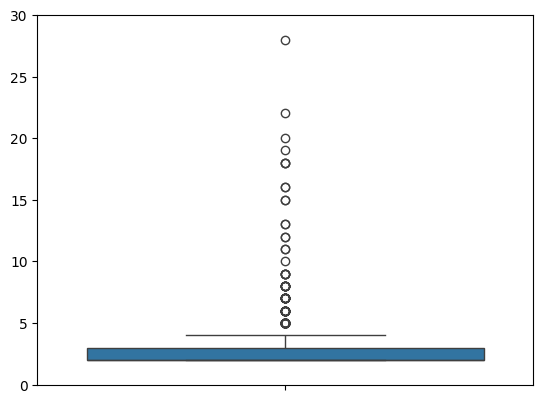

In [61]:
f = np.array([len(i) for i in louvain_w])
plt.figure()
sns.boxplot(f)
plt.ylim(0, 30)
plt.show()

In [ ]:
w2v_graph_w_verbs_2 = nx.Graph()
for word in tqdm(model.index_to_key):
    if 'VERB' in word:
        for neigh, weight in model.most_similar(word, topn=10):
            if 'VERB' in neigh:# and weight > 0.7:
                w2v_graph_w_verbs_2.add_edge(word, neigh, weight=-weight)
w2v_graph_w_verbs_2.remove_nodes_from(nx.isolates(w2v_graph_w_verbs_2))

100%|██████████| 195071/195071 [05:31<00:00, 588.09it/s] 


In [89]:
louvain_w_2 = nx.algorithms.community.louvain_communities(w2v_graph_w_verbs_2, weight='weight', resolution=100)
len(louvain_w_2)

1682

In [105]:
get_cluster(louvain_w_2, 'анализировать_VERB')

[{'анализировать_VERB',
  'верифицировать_VERB',
  'группировать_VERB',
  'группироваться_VERB',
  'группируться_VERB',
  'документироваться_VERB',
  'дополниться_VERB',
  'истематизировать_VERB',
  'каталогизировать_VERB',
  'классифицировать_VERB',
  'обобщать_VERB',
  'обобщаться_VERB',
  'обобщающий_VERB',
  'обобщенный_VERB',
  'обобщить_VERB',
  'объединяемый_VERB',
  'оперировать_VERB',
  'оперируть_VERB',
  'последующий_VERB',
  'предварять_VERB',
  'предваряться_VERB',
  'предпослать_VERB',
  'предпосылать_VERB',
  'предшествовавать_VERB',
  'предшествовавший_VERB',
  'предшествовать_VERB',
  'предшествующий_VERB',
  'прерванный_VERB',
  'примыкать_VERB',
  'проанализировать_VERB',
  'сгруппировать_VERB',
  'сгруппироваться_VERB',
  'систематизировать_VERB',
  'систематизируться_VERB',
  'сопоставить_VERB',
  'сопоставливать_VERB',
  'сопоставлять_VERB',
  'сравнивать_VERB',
  'сравнимый_VERB',
  'сравнить_VERB',
  'суммируть_VERB',
  'уммировать_VERB',
  'характеризовавший_VE

In [103]:
from spellchecker import SpellChecker

spell = SpellChecker(language='ru')
'колотить' in spell

False

### фильтруем

In [80]:
import pymorphy3

In [81]:
morph = pymorphy3.MorphAnalyzer(lang='ru')
def is_lemmatized_word(word):
    word = word.lower()    
    parsings = morph.parse(word)
    if parsings:
        if any((p.is_known and 'INFN' in p.tag) for p in parsings):
            return True
    return False

In [82]:
w2v_graph_w_verbs_2_filtered = nx.Graph()
for word in tqdm(model.index_to_key):
    if 'VERB' in word and is_lemmatized_word(word.split('_')[0]):
        for neigh, weight in model.most_similar(word, topn=10):
            if 'VERB' in neigh and is_lemmatized_word(neigh.split('_')[0]):# and weight > 0.7:
                w2v_graph_w_verbs_2_filtered.add_edge(word, neigh, weight=-weight)
w2v_graph_w_verbs_2_filtered.remove_nodes_from(nx.isolates(w2v_graph_w_verbs_2_filtered))

100%|██████████| 195071/195071 [02:53<00:00, 1123.19it/s]


In [83]:
len(w2v_graph_w_verbs_2_filtered.nodes)

15979

In [84]:
louvain_w_2_filtered = nx.algorithms.community.louvain_communities(w2v_graph_w_verbs_2_filtered, weight='weight', resolution=100)
len(louvain_w_2_filtered)

1204

In [ ]:
get_cluster(louvain_w_2_filtered, 'дискутировать_VERB')

[{'будировать_VERB',
  'выверить_VERB',
  'выверять_VERB',
  'дебатировать_VERB',
  'дебатироваться_VERB',
  'дискутировать_VERB',
  'дискутироваться_VERB',
  'муссировать_VERB',
  'обдумать_VERB',
  'обдумывать_VERB',
  'обсудить_VERB',
  'обсуждать_VERB',
  'обсуждаться_VERB',
  'продумать_VERB',
  'продумывать_VERB',
  'рассматривать_VERB',
  'рассматриваться_VERB',
  'рассмотреть_VERB'}]

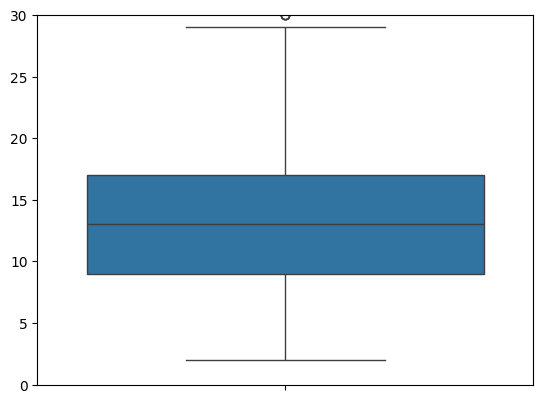

In [120]:
f = np.array([len(i) for i in louvain_w_2_filtered])
plt.figure()
sns.boxplot(f)
plt.ylim(0, 30)
plt.show()